# College Football Spread Model

Predicting **margin of victory** and comparing it against the **market spread** to look for edges.

The point of this project is not the model architecture. It is the validation discipline:

- **Point-in-time features.** Every feature for a game uses only information available *before* kickoff. No future leakage.
- **Walk-forward validation.** To predict a season, train only on earlier seasons.
- **Graded against the market.** The headline number is model margin error vs the spread's margin error. The market is extremely good, so beating it is hard, and that honesty is the point.

This notebook runs the whole pipeline from cached data and shows the real result.

## 1. Setup

In [3]:
import sys, os
sys.path.insert(0, os.path.abspath("."))   # so `import cfb` works from the repo root

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cfb.features import point_in_time_team_features, build_model_table, FEATURE_COLS
from cfb.model import walk_forward_backtest, grade
from cfb.config import MIN_WEEK, SHRINK_K

pd.set_option("display.max_columns", 50)
print("Imports OK. Feature columns:", FEATURE_COLS)

Imports OK. Feature columns: ['off_ppa_diff', 'def_ppa_diff', 'success_rate_diff', 'explosiveness_diff', 'scoring_margin_diff', 'home_field']


## 2. Load the raw data

These two files are produced by `scripts/01_fetch.py` from the CollegeFootballData API.
They are gitignored (data is not committed), so run the fetch once locally to create them.

In [4]:
team_games = pd.read_parquet("data/raw/team_games.parquet")
games = pd.read_parquet("data/raw/games.parquet")

print(f"team-games: {team_games.shape}")
print(f"games:      {games.shape}")
print(f"seasons:    {sorted(games['season'].unique())}")
team_games.head(3)

team-games: (10484, 12)
games:      (13401, 9)
seasons:    [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


,game_id,season,week,team,points_for,points_against,off_ppa,def_ppa,off_success_rate,def_success_rate,off_explosiveness,def_explosiveness
0,401282714,2021,1,Illinois,30,22,0.044854,0.320845,0.455882,0.422535,0.966775,1.435771
1,401282714,2021,1,Nebraska,22,30,0.320845,0.044854,0.422535,0.455882,1.435771,0.966775
2,401286187,2021,1,Fresno State,45,0,0.290790,-0.396563,0.493506,0.163934,1.180446,1.126576


## 3. Build point-in-time features

The single rule that makes this honest lives in `cfb/features.py`:

```python
prior_mean = grp[col].transform(lambda s: s.shift(1).expanding().mean())
```

`shift(1)` drops the current game, so a team's feature for a given week is the average of its
**prior** games only. Early-season estimates are shrunk toward a fixed league baseline so that
a team with 3 games played is not trusted as much as one with 10.

In [5]:
features = point_in_time_team_features(team_games, shrink_k=SHRINK_K)
features[["season", "week", "team", "n_prior", "off_ppa_pit", "points_for_pit"]].head(6)

,season,week,team,n_prior,off_ppa_pit,points_for_pit
123,2021,1,Abilene Christian,0,0.000000,28.000000
80,2021,1,Air Force,0,0.000000,28.000000
243,2021,2,Air Force,1,0.074902,29.400000
462,2021,3,Air Force,2,0.054818,28.333333
608,2021,4,Air Force,3,0.107152,30.714286
709,2021,5,Air Force,4,0.137888,30.750000


## 4. Prove there is no future leakage

This is the most important cell in the notebook. The check corrupts every game from a chosen
week onward and confirms that no earlier feature changes. If a future game could move a past
feature, every result below would be worthless.

In [6]:
from tests.test_no_leakage import test_no_future_leak, test_first_game_equals_prior
test_no_future_leak()
test_first_game_equals_prior()

PASS  no future leak (corrupted week >= 7, 192 past team-games checked, all unchanged)
PASS  first game equals prior (32 first-games checked)


## 5. Assemble the model table

One row per game, from the home team's perspective: feature differences, the actual margin,
and the market spread side by side. Filtered to Week 4 and later.

In [7]:
model_table = build_model_table(features, games, min_week=MIN_WEEK)
print(f"{len(model_table)} games (Week {MIN_WEEK}+)")
model_table[["season","week","home_team","away_team","off_ppa_diff",
             "scoring_margin_diff","spread_home","margin"]].head()

3912 games (Week 4+)


,season,week,home_team,away_team,off_ppa_diff,scoring_margin_diff,spread_home,margin
0,2021,4,App State,Marshall,-0.017099,-3.714286,-7.0,1
1,2021,4,Charlotte,Middle Tennessee,0.083609,2.857143,-2.5,3
2,2021,4,Virginia,Wake Forest,0.090103,-3.857143,-3.5,-20
3,2021,4,Syracuse,Liberty,-0.020628,-4.142857,6.5,3
4,2021,4,Fresno State,UNLV,0.178764,22.321429,-30.0,8


In [15]:
print(model_table[FEATURE_COLS].std())

off_ppa_diff           0.096042
def_ppa_diff           0.087496
success_rate_diff      0.043794
explosiveness_diff     0.103346
scoring_margin_diff    9.823951
home_field             0.154738
dtype: float64


## 6. Walk-forward backtest

Train on past seasons, predict the next. A regularized linear model (RidgeCV) on the feature
differences. Simple and defensible: easy to beat a black box on trust, hard to beat on this task.

In [8]:
preds = walk_forward_backtest(model_table)
preds[["season","week","home_team","away_team","model_margin","spread_home","margin"]].head()

  2021: skipped (only 0 prior rows to train on)
  2022: trained on 605 games, predicted 1050
  2023: trained on 1655 games, predicted 1076
  2024: trained on 2731 games, predicted 1181


/Users/tylerseroczynski/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/tylerseroczynski/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/tylerseroczynski/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/tylerseroczynski/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/tylerseroczynski/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/tylerseroczynski/Library/Python/3.9/lib/p

,season,week,home_team,away_team,model_margin,spread_home,margin
0,2022,4,Virginia Tech,West Virginia,4.815670,2.0,-23
1,2022,4,Georgia State,Coastal Carolina,-5.970351,2.5,-17
2,2022,4,Illinois,Chattanooga,2.819068,-20.0,31
3,2022,4,Syracuse,Virginia,10.431666,-9.5,2
4,2022,4,Air Force,Nevada,15.743166,-24.0,28


## 7. Grade it against the market

In [9]:
grade(preds)


=== Accuracy at predicting actual margin (lower is better) ===
  Model  MAE: 13.45 points
  Vegas  MAE: 11.96 points   <- the bar
  Model does NOT beat the spread on margin error (+1.50).

=== If you bet every game the model disagreed with by >= threshold ===
  thr   bets    win%   ROI/bet   (break-even win% = 52.4)
    0   3105     51.1    -0.024
    1   2735     51.0    -0.027
    2   2356     50.7    -0.032
    3   2039     50.8    -0.030
    4   1732     50.9    -0.029
    6   1221     51.2    -0.023

Reading it: if win% sits around 50 and ROI is negative, the model is not beating the market yet. That is the normal, honest starting point. Real edges are small and survive only at higher thresholds, if at all.


## 8. Visualize

Two pictures: how the model's margin error stacks up against the market, and how the model's
predicted margins line up with what actually happened.

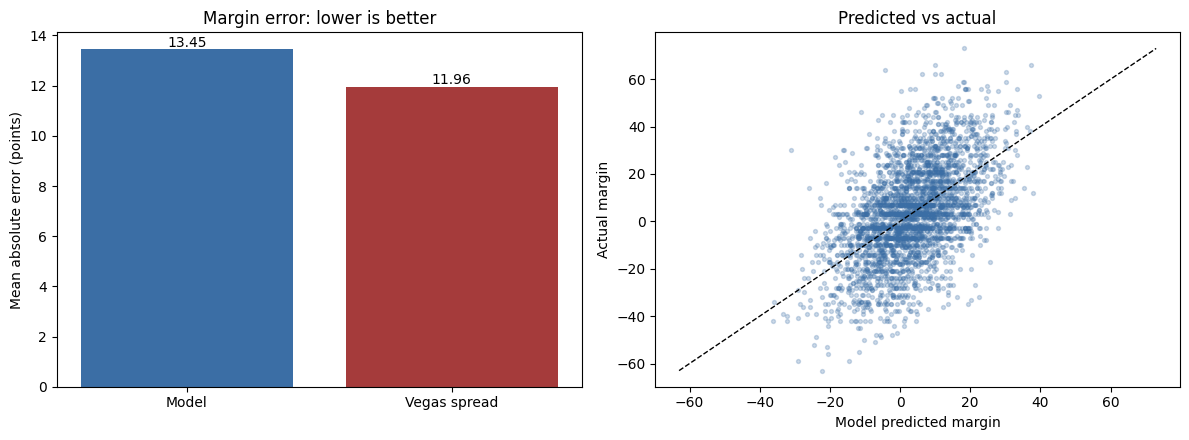

In [10]:
g = preds.dropna(subset=["spread_home"]).copy()
g["market_margin"] = -g["spread_home"]
model_mae = (g["model_margin"] - g["margin"]).abs().mean()
spread_mae = (g["market_margin"] - g["margin"]).abs().mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(["Model", "Vegas spread"], [model_mae, spread_mae],
            color=["#3b6ea5", "#a53b3b"])
axes[0].set_ylabel("Mean absolute error (points)")
axes[0].set_title("Margin error: lower is better")
for i, v in enumerate([model_mae, spread_mae]):
    axes[0].text(i, v + 0.1, f"{v:.2f}", ha="center")

axes[1].scatter(g["model_margin"], g["margin"], s=8, alpha=0.25, color="#3b6ea5")
lim = [g["margin"].min(), g["margin"].max()]
axes[1].plot(lim, lim, "k--", lw=1)
axes[1].set_xlabel("Model predicted margin")
axes[1].set_ylabel("Actual margin")
axes[1].set_title("Predicted vs actual")

plt.tight_layout()
plt.show()

## 9. Read of the results, and what comes next

Expect the market to beat this model on margin error, and the betting ROI to sit near or below
break-even. That is the correct, honest baseline for a first model on six basic features. If it
had beaten the closing line on attempt one, the right move would be to hunt for a data leak, not
to celebrate.

What moves the number from here, in order:

1. **Better features.** Six raw differentials is thin. Opponent-adjusted efficiency, pace, and
   recent-form weighting are where real signal lives.
2. **Opening vs closing lines.** Capturing both lets us measure true closing line value, the only
   repeatable proof of skill.
3. **Situational coaching context** as careful features, not noise. Most big-game splits have tiny
   samples and belong in the writeup, not the model.

The pipeline underneath all of that is validated and leak-free, which is the part that makes any
future result trustworthy.

In [11]:
from sklearn.linear_model import Ridge

def add_opponent(team_games):
    """Attach each team-game's opponent by pairing the two rows that share a game_id."""
    pairs = team_games[['game_id','team']]
    m = pairs.merge(pairs, on='game_id', suffixes=('','_opp'))
    m = m[m['team'] != m['team_opp']].rename(columns={'team_opp':'opponent'})
    return team_games.merge(m, on=['game_id','team'], how='left')

def _fit_ratings(prior, alpha):
    # Solve: a team's offensive ppa = its offense rating + the opponent's defense effect.
    # Ridge shrinks toward league average, which handles thin early-season samples.
    O = pd.get_dummies(prior['team']).add_prefix('off_')
    D = pd.get_dummies(prior['opponent']).add_prefix('def_')
    X = pd.concat([O, D], axis=1).fillna(0).astype(float)
    model = Ridge(alpha=alpha, fit_intercept=True)
    model.fit(X.values, prior['off_ppa'].astype(float).values)
    return dict(zip(X.columns, model.coef_))

def adjusted_ratings_point_in_time(team_games, alpha=30.0):
    """For each game, ratings computed ONLY from earlier weeks that season (leak-safe)."""
    tg = team_games.dropna(subset=['off_ppa','opponent']).copy()
    rows = []
    for season, sdf in tg.groupby('season'):
        for w in sorted(sdf['week'].unique()):
            prior = sdf[sdf['week'] < w]
            cur = sdf[sdf['week'] == w]
            if len(prior) < 20:                     # too little history to adjust yet
                for _, r in cur.iterrows():
                    rows.append((r['game_id'], r['team'], 0.0, 0.0))
                continue
            coef = _fit_ratings(prior, alpha)
            for _, r in cur.iterrows():
                rows.append((r['game_id'], r['team'],
                             coef.get('off_'+str(r['team']), 0.0),
                             coef.get('def_'+str(r['team']), 0.0)))
    return pd.DataFrame(rows, columns=['game_id','team','adj_off','adj_def'])

def attach_adjusted(model_table, adj):
    """Add opponent-adjusted off/def diffs to the model table."""
    h = adj.rename(columns={'team':'home_team','adj_off':'home_adj_off','adj_def':'home_adj_def'})
    a = adj.rename(columns={'team':'away_team','adj_off':'away_adj_off','adj_def':'away_adj_def'})
    mt = (model_table.merge(h, on=['game_id','home_team'], how='left')
                     .merge(a, on=['game_id','away_team'], how='left'))
    mt['adj_off_diff'] = mt['home_adj_off'] - mt['away_adj_off']
    mt['adj_def_diff'] = mt['home_adj_def'] - mt['away_adj_def']
    return mt

print("opponent-adjustment functions loaded")

opponent-adjustment functions loaded


In [12]:
team_games_opp = add_opponent(team_games)
adj = adjusted_ratings_point_in_time(team_games_opp, alpha=30.0)
model_table_adj = attach_adjusted(model_table, adj)

print("adjusted ratings computed for", len(adj), "team-games")
adj.sort_values("adj_off", ascending=False).head(8)   # your top offenses by adjusted rating

/Users/tylerseroczynski/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/tylerseroczynski/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/tylerseroczynski/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/tylerseroczynski/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/tylerseroczynski/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/tylerseroczynski/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/tylerseroczynski/

adjusted ratings computed for 10484 team-games


/Users/tylerseroczynski/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/tylerseroczynski/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/tylerseroczynski/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/tylerseroczynski/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/tylerseroczynski/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/tylerseroczynski/Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/tylerseroczynski/

,game_id,team,adj_off,adj_def
7248,401520433,LSU,0.099420,0.022645
7351,401539475,Oregon,0.088574,-0.037096
7204,401520409,LSU,0.086931,0.023304
7246,401524063,Oregon,0.084524,-0.031767
4515,401507652,Incarnate Word,0.083352,-0.031739
4488,401506571,Incarnate Word,0.083246,-0.031219
7114,401540353,South Dakota State,0.077109,-0.040291
6948,401520389,LSU,0.076144,0.019529


In [13]:
def mae(p):
    gg = p.dropna(subset=['spread_home']).copy()
    return (gg['model_margin'] - gg['margin']).abs().mean()

base = walk_forward_backtest(model_table, feature_cols=FEATURE_COLS)
adjm = walk_forward_backtest(model_table_adj, feature_cols=FEATURE_COLS + ['adj_off_diff','adj_def_diff'])

print(f"\nBaseline MAE (6 features):       {mae(base):.3f}")
print(f"Opponent-adjusted MAE (8):       {mae(adjm):.3f}")
print(f"Vegas MAE was ~11.96, for reference")

  2021: skipped (only 0 prior rows to train on)
  2022: trained on 605 games, predicted 1050
  2023: trained on 1655 games, predicted 1076
  2024: trained on 2731 games, predicted 1181
  2021: skipped (only 0 prior rows to train on)
  2022: trained on 605 games, predicted 1050
  2023: trained on 1655 games, predicted 1076
  2024: trained on 2731 games, predicted 1181

Baseline MAE (6 features):       13.453
Opponent-adjusted MAE (8):       13.330
Vegas MAE was ~11.96, for reference


/Users/tylerseroczynski/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/tylerseroczynski/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/tylerseroczynski/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/tylerseroczynski/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/tylerseroczynski/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/tylerseroczynski/Library/Python/3.9/lib/p

In [14]:
from cfb.fetch_data import _get
import json
sample = _get("/games/teams", {"year": 2023, "week": 5})
print(json.dumps(sample[0], indent=2)[:1500])

/Users/tylerseroczynski/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


{
  "id": 401531339,
  "teams": [
    {
      "teamId": 218,
      "team": "Temple",
      "conference": "American Athletic",
      "homeAway": "away",
      "points": 26,
      "stats": [
        {
          "category": "firstDowns",
          "stat": "15"
        },
        {
          "category": "thirdDownEff",
          "stat": "6-18"
        },
        {
          "category": "fourthDownEff",
          "stat": "3-6"
        },
        {
          "category": "totalYards",
          "stat": "313"
        },
        {
          "category": "netPassingYards",
          "stat": "269"
        },
        {
          "category": "completionAttempts",
          "stat": "27-49"
        },
        {
          "category": "yardsPerPass",
          "stat": "5.5"
        },
        {
          "category": "rushingYards",
          "stat": "44"
        },
        {
          "category": "rushingAttempts",
          "stat": "21"
        },
        {
          "category": "yardsPerRushAttempt",
